# 09 — Benchmark report

Visualises the chunking × embedding × LLM sweep produced by
`python -m rag_evals.scripts.benchmark`. The script writes
`report/benchmark.json`; this notebook loads it and renders the same
tables + a few charts.

Re-run `make benchmark` (or the script directly) to refresh the JSON.


In [1]:
import json, pandas as pd
from pathlib import Path
bench = json.loads(Path("../report/benchmark.json").read_text())
print({k: type(v).__name__ for k, v in bench.items()})
bench["settings"]


{'settings': 'dict', 'chunking_sweep': 'list', 'embedding_sweep': 'list', 'llm_sweep': 'list', 'pairwise': 'list'}


{'n_docs': 800,
 'n_queries': 30,
 'n_llm_queries': 15,
 'default_embedding': 'BAAI/bge-small-en-v1.5',
 'default_collection': 'scifact'}

## Chunking sweep — embedding fixed, chunking varied


In [2]:
df_chunk = pd.DataFrame(bench["chunking_sweep"])
if not df_chunk.empty:
    cols = ["config", "n_chunks", "index_secs", "recall_at_10", "mrr", "ndcg_at_10", "map", "coverage"]
    display(df_chunk[cols].set_index("config"))


,n_chunks,index_secs,recall_at_10,mrr,ndcg_at_10,map,coverage
config,,,,,,,
recursive_256_32,1453,70.35,0.9000,0.7215,0.7596,0.7215,1.0
recursive_128_16,1593,77.88,0.8333,0.7104,0.7322,0.7104,1.0
recursive_512_64,895,43.44,0.8333,0.5842,0.6409,0.5842,1.0
structural_256,1453,68.22,0.9000,0.7215,0.7596,0.7215,1.0


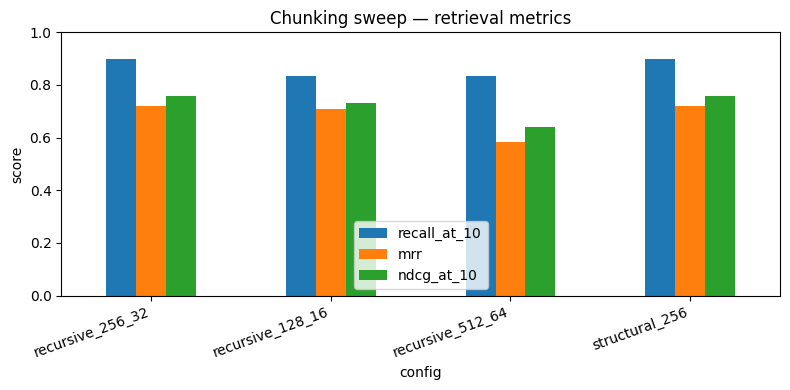

In [3]:
import matplotlib.pyplot as plt
if not df_chunk.empty:
    ax = df_chunk.set_index("config")[["recall_at_10", "mrr", "ndcg_at_10"]].plot(
        kind="bar", figsize=(8, 4), title="Chunking sweep — retrieval metrics"
    )
    ax.set_ylabel("score")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


## Embedding sweep — chunking fixed, embedding varied


In [4]:
df_emb = pd.DataFrame(bench["embedding_sweep"])
if not df_emb.empty:
    cols = ["config", "n_chunks", "index_secs", "recall_at_10", "mrr", "ndcg_at_10", "map", "coverage"]
    display(df_emb[cols].set_index("config"))


,n_chunks,index_secs,recall_at_10,mrr,ndcg_at_10,map,coverage
config,,,,,,,
bge-small-en-v1.5,1453,69.36,0.9000,0.7215,0.7596,0.7215,1.0000
all-MiniLM-L6-v2,1453,9.95,0.8333,0.6619,0.7009,0.6619,0.9583
bge-base-en-v1.5,1453,147.25,1.0000,0.7737,0.8283,0.7737,1.0000


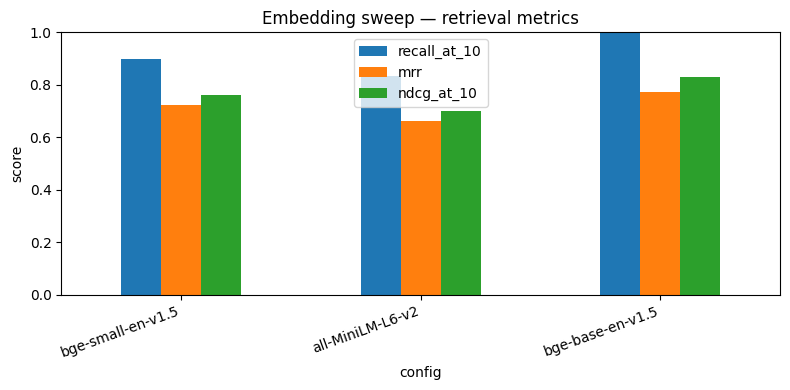

In [5]:
if not df_emb.empty:
    ax = df_emb.set_index("config")[["recall_at_10", "mrr", "ndcg_at_10"]].plot(
        kind="bar", figsize=(8, 4), title="Embedding sweep — retrieval metrics"
    )
    ax.set_ylabel("score")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


## LLM sweep — generator varies


In [6]:
df_llm = pd.DataFrame(bench["llm_sweep"])
if not df_llm.empty:
    display(df_llm.set_index("model"))


,backend_mode,n_queries,avg_latency_ms,p95_latency_ms,faithfulness_heuristic,faithfulness_llm,n_failures,sample_answer
model,,,,,,,,
gpt-5-mini,live,15,4008.0,4915.9,0.2200,0.4460,0,I don't know.…
claude-haiku-4-5,live,15,2309.8,2485.7,0.1463,0.7821,0,I don't know. The provided context does not co...
gemini/gemini-2.5-flash,live,15,2916.1,4102.2,0.3278,0.6022,0,I don't know.…


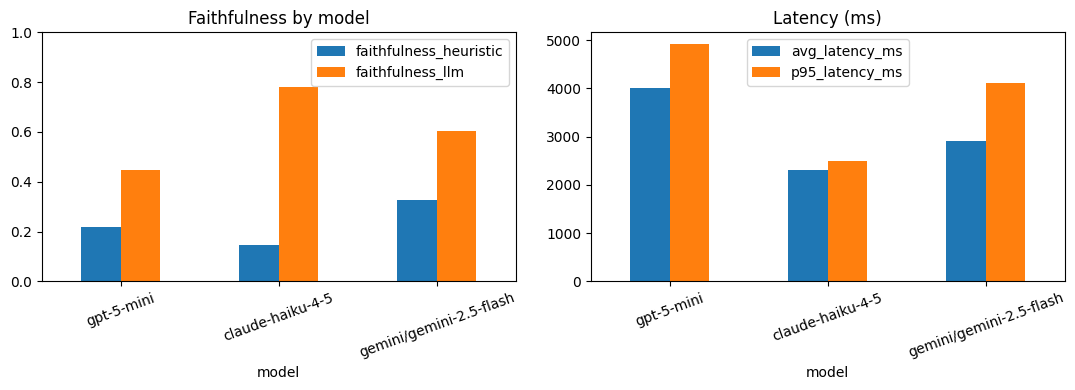

In [7]:
if not df_llm.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    df_llm.set_index("model")[["faithfulness_heuristic", "faithfulness_llm"]].plot(
        kind="bar", ax=axes[0], title="Faithfulness by model"
    )
    axes[0].set_ylim(0, 1)
    df_llm.set_index("model")[["avg_latency_ms", "p95_latency_ms"]].plot(
        kind="bar", ax=axes[1], title="Latency (ms)"
    )
    for ax in axes:
        ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()


## Pairwise judging (cross-family judge)


In [8]:
df_pw = pd.DataFrame(bench.get("pairwise", []))
if not df_pw.empty:
    display(df_pw)
else:
    print("no pairwise data — re-run with live LLM keys to populate")


,judge,a,b,a_wins,b_wins,ties,winrate_a
0,gemini/gemini-2.5-flash,gpt-5-mini,claude-haiku-4-5,6,9,0,0.400000
1,claude-haiku-4-5,gpt-5-mini,gemini/gemini-2.5-flash,10,5,0,0.666667
2,gpt-5-mini,claude-haiku-4-5,gemini/gemini-2.5-flash,11,4,0,0.733333
